In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.constants import R

In [164]:
df = pd.read_csv("dat.tsv", sep='\t')
df['Temperature'] += 273.15
df

,Temperature,[HCl],[Iodine],[Acetone],[Water],Rate
0,302.713009,0.024107,0.002129,1.990460,44.873879,4.703519e-06
1,309.717437,0.023087,0.002386,1.985887,44.806541,1.259816e-05
2,306.051011,0.022223,0.002082,1.957734,45.138267,7.339933e-06
3,302.557199,0.011339,0.002293,1.980991,45.530455,2.169842e-06
4,302.514833,0.040817,0.001998,1.967061,44.114360,7.572028e-06
5,302.416572,0.020536,0.004176,1.953436,44.086957,3.571443e-06
6,302.711582,0.020939,0.001026,1.991848,45.656391,4.460606e-06
7,302.415952,0.020088,0.003012,0.465670,50.831232,7.334901e-07
8,302.888055,0.020694,0.002148,4.034431,36.708748,8.205428e-06


In [165]:
X = df[['Temperature', '[HCl]', '[Iodine]', '[Acetone]']].to_numpy()
X

array([[3.02713009e+02, 2.41072367e-02, 2.12883074e-03, 1.99046006e+00],
       [3.09717437e+02, 2.30867619e-02, 2.38578629e-03, 1.98588749e+00],
       [3.06051011e+02, 2.22226659e-02, 2.08171565e-03, 1.95773430e+00],
       [3.02557199e+02, 1.13387808e-02, 2.29271085e-03, 1.98099062e+00],
       [3.02514833e+02, 4.08170078e-02, 1.99791740e-03, 1.96706077e+00],
       [3.02416572e+02, 2.05358576e-02, 4.17557370e-03, 1.95343571e+00],
       [3.02711582e+02, 2.09393908e-02, 1.02598351e-03, 1.99184841e+00],
       [3.02415952e+02, 2.00876516e-02, 3.01237928e-03, 4.65669790e-01],
       [3.02888055e+02, 2.06935563e-02, 2.14764728e-03, 4.03443122e+00]])

# nonlinear regression

In [166]:
def rate_equation(x, lnA, Ea, alpha, beta, gamma):
    x = np.asarray(x)
    T = x[:, 0]
    C_HCl = x[:, 1]
    C_I = x[:, 2]
    C_A = x[:, 3]
    k = np.exp(lnA) * np.exp(-Ea / (R * T))
    return k * (C_A**alpha) * (C_HCl**beta) * (C_I**gamma)

popt, pcov = curve_fit(rate_equation, X, df['Rate'].to_numpy(), p0=[35, 90000, 1, 1, 0])

In [167]:
perr = np.sqrt(np.diag(pcov))
param_names = ['ln(A)', 'Ea', 'alpha', 'beta', 'gamma']

for name, val, err in zip(param_names, popt, perr):
    print(f"{name} = {val:.4f} ± {err:.4f}")

ln(A) = 35.9530 ± 0.8496
Ea = 115725.9441 ± 2153.6745
alpha = 0.9563 ± 0.0314
beta = 0.9606 ± 0.0352
gamma = -0.1115 ± 0.0358


In [168]:
y_pred = rate_equation(X, *popt)
y_true = df['Rate'].to_numpy()

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r_squared = 1 - ss_res / ss_tot
print(f"R squared = {r_squared:.6f}")

R squared = 0.999194


In [169]:
from scipy import stats

# Calculate 95% confidence intervals for each parameter
confidence_level = 0.95
alpha = 1 - confidence_level
t_value = stats.t.ppf(1 - alpha/2, len(y_true) - len(popt))

print("95% Confidence Intervals:")
print("-" * 50)
for name, val, err in zip(param_names, popt, perr):
    ci_lower = val - t_value * err
    ci_upper = val + t_value * err
    print(f"{name}: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% Confidence Intervals:
--------------------------------------------------
ln(A): [33.5940, 38.3120]
Ea: [109746.3850, 121705.5032]
alpha: [0.8691, 1.0436]
beta: [0.8629, 1.0583]
gamma: [-0.2108, -0.0121]


### second iteration

now, rounding gamma to 0 and rounding alpha,beta to 1

In [170]:
def rate_equation(x, lnA, Ea):
    '''alpha = 1, beta = 1, gamma = 0'''
    x = np.asarray(x)
    T = x[:, 0]
    C_HCl = x[:, 1]
    C_I = x[:, 2]
    C_A = x[:, 3]
    k = np.exp(lnA) * np.exp(-Ea / (R * T))
    return k * (C_A**1) * (C_HCl**1)

popt, pcov = curve_fit(rate_equation, X, df['Rate'].to_numpy(), p0=[35, 115725])
perr = np.sqrt(np.diag(pcov))
param_names = ['A', 'Ea']

print('--- fit results ---')
for name, val, err in zip(param_names, popt, perr):
    print(f"{name} = {val:.3f} ± {err:.3f}")

--- fit results ---
A = 36.709 ± 1.032
Ea = 115629.209 ± 2625.229


In [171]:
y_pred = rate_equation(X, *popt)
y_true = df['Rate'].to_numpy()

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r_squared = 1 - ss_res / ss_tot
print(f"R squared = {r_squared:.6f}")

R squared = 0.996744


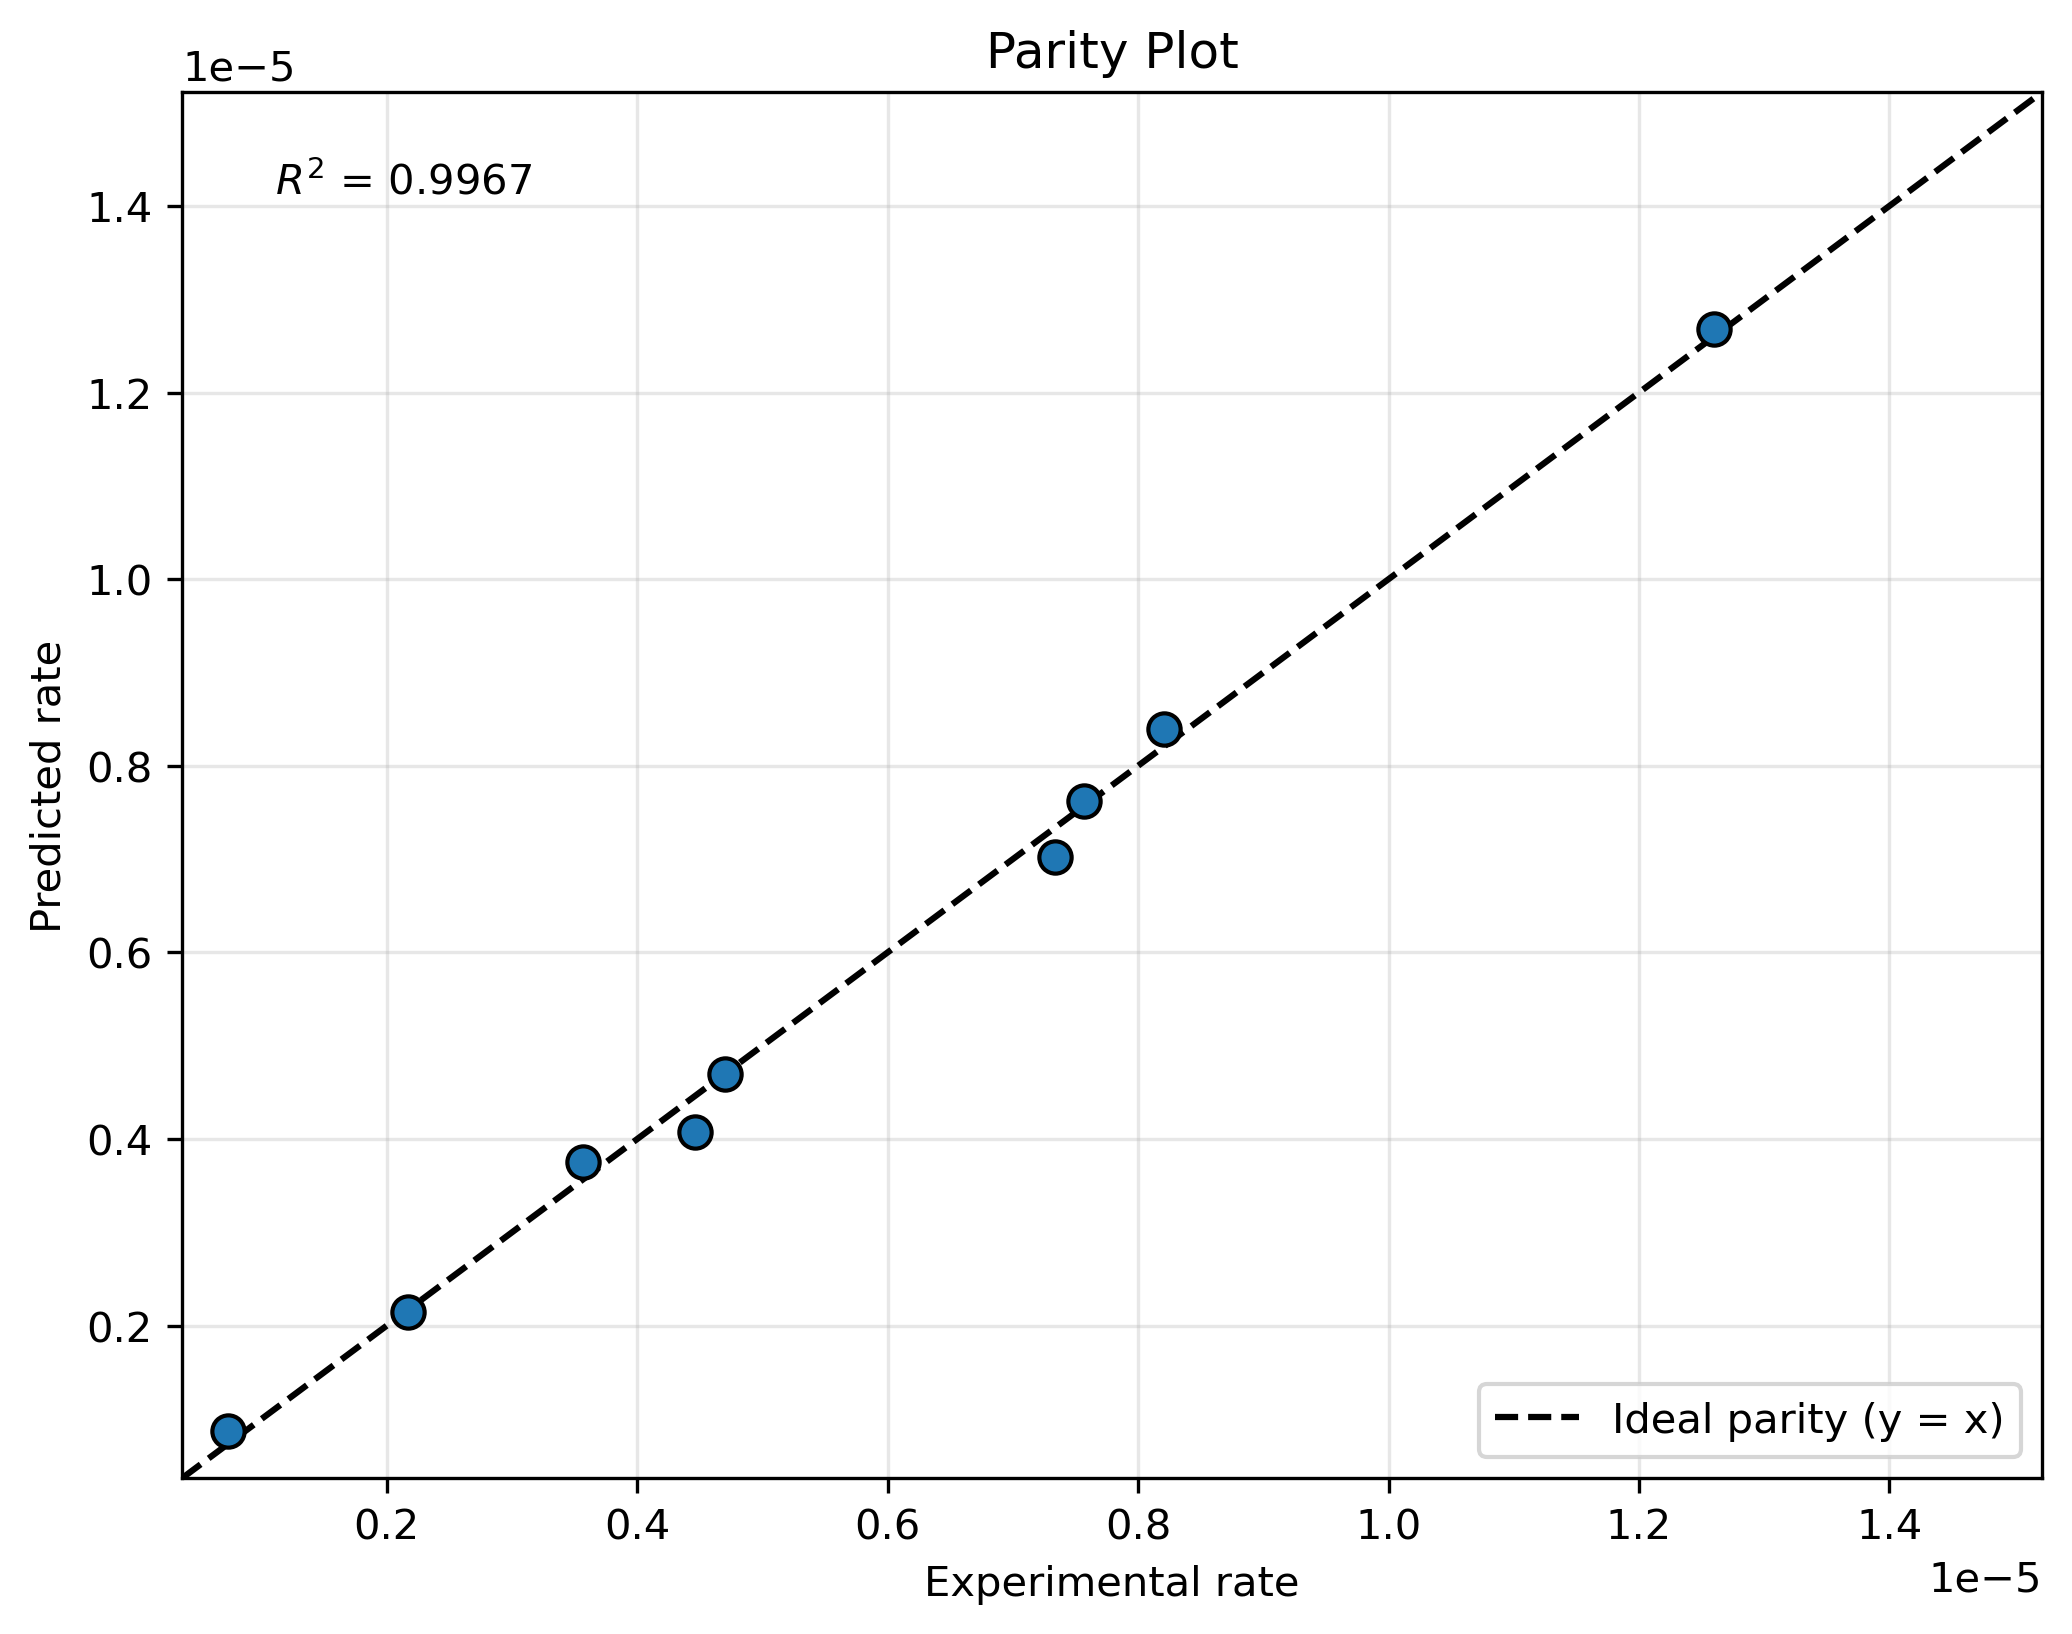

In [172]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.scatter(y_true, y_pred, s=60, alpha=1.0, edgecolor='black', zorder=100)

lims = [
    min(y_true.min()*0.5, y_pred.min()*0.5),
    max(y_true.max()*1.2, y_pred.max()*1.2)
]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal parity (y = x)')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Experimental rate')
ax.set_ylabel('Predicted rate')
ax.set_title('Parity Plot')
ax.text(0.05, 0.95, f'$R^2$ = {r_squared:.4f}', transform=ax.transAxes, va='top')
ax.grid(True, alpha=0.3)
ax.legend()
